# House Price Prediction

This notebook trains and evaluates a house-price prediction workflow using the Kaggle `house_price_50k.csv` dataset. It is written to run locally or in Google Colab.

## 1. Project overview

The project predicts house prices from property and neighbourhood features. The notebook reproduces the figures, metrics and Tableau exports used in the final report.

## 2. Business problem

A property analyst needs a consistent first estimate before making a final pricing decision. The model supports that decision by giving a baseline price and showing the strongest drivers.

## 3. Environment setup

In [18]:
from pathlib import Path
import os
import urllib.request

RANDOM_STATE = 42
GITHUB_RAW_DATA_URL = ""  # TODO: add after GitHub publication

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
TABLEAU_DIR = PROJECT_ROOT / "tableau-pack"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLEAU_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "house_price_50k.csv"
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)

Project root: /content
Dataset path: /content/data/house_price_50k.csv


## 4. Library imports

In [19]:
try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 220})

## 5. Data loading

The notebook first looks for `data/house_price_50k.csv`. In Colab, you may upload the CSV into the runtime. After GitHub publication, the raw URL placeholder can be filled in.

In [20]:
import shutil

def find_or_load_dataset() -> Path:
    # Check for various possible paths, including the one Colab might have renamed it to
    candidates = [
        DATA_PATH,
        PROJECT_ROOT / "house_price_50k.csv",
        Path.cwd() / "house_price_50k.csv",
        Path("/content/house_price_50k.csv"),
        Path("/content/house_price_50k (1).csv"),
    ]

    for candidate in candidates:
        if candidate.exists():
            if candidate != DATA_PATH:
                # Ensure the data directory exists and copy the file to the expected DATA_PATH
                DATA_DIR.mkdir(parents=True, exist_ok=True)
                shutil.copy(candidate, DATA_PATH)
            return DATA_PATH

    if GITHUB_RAW_DATA_URL:
        urllib.request.urlretrieve(GITHUB_RAW_DATA_URL, DATA_PATH)
        return DATA_PATH

    try:
        from google.colab import files
        print("Dataset not found. Please upload house_price_50k.csv.")
        uploaded = files.upload()
        # Handle case where file might be named differently or has (1) suffix
        uploaded_name = next((name for name in uploaded.keys() if "house_price_50k" in name), None)

        if not uploaded_name:
            raise FileNotFoundError("Please upload a file named house_price_50k.csv.")

        DATA_PATH.write_bytes(uploaded[uploaded_name])
        return DATA_PATH
    except ModuleNotFoundError:
        raise FileNotFoundError(
            "Dataset not found. Place house_price_50k.csv in the data/ folder."
        )

dataset_path = find_or_load_dataset()
df = pd.read_csv(dataset_path)
df.columns = [c.strip().lower() for c in df.columns]
print(f"Loaded dataset with shape: {df.shape}")
display(df.head())

Loaded dataset with shape: (50000, 19)


,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1.792425e+06


## 6. Dataset inspection

In [21]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.dtypes)
df.describe(include="all").transpose().head(25)

Rows: 50000
Columns: 19
area                      int64
bedrooms                  int64
bathrooms                 int64
floors                    int64
age                       int64
distance                  int64
garage                    int64
parking                   int64
garden                    int64
security                  int64
school_nearby             int64
hospital_nearby           int64
shopping_mall_nearby      int64
public_transport          int64
crime_rate              float64
population_density        int64
location                 object
income_level             object
price                   float64
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area,50000.0,NaN,NaN,NaN,2752.97054,1297.148134,500.0,1630.0,2756.0,3872.0,4999.0
bedrooms,50000.0,NaN,NaN,NaN,3.49604,1.712146,1.0,2.0,3.0,5.0,6.0
bathrooms,50000.0,NaN,NaN,NaN,2.49804,1.117704,1.0,1.0,2.0,3.0,4.0
floors,50000.0,NaN,NaN,NaN,1.99706,0.815368,1.0,1.0,2.0,3.0,3.0
age,50000.0,NaN,NaN,NaN,19.57374,11.552502,0.0,10.0,20.0,30.0,39.0
distance,50000.0,NaN,NaN,NaN,14.9687,8.363714,1.0,8.0,15.0,22.0,29.0
garage,50000.0,NaN,NaN,NaN,0.50054,0.500005,0.0,0.0,1.0,1.0,1.0
parking,50000.0,NaN,NaN,NaN,0.4973,0.499998,0.0,0.0,0.0,1.0,1.0
garden,50000.0,NaN,NaN,NaN,0.50028,0.500005,0.0,0.0,1.0,1.0,1.0
security,50000.0,NaN,NaN,NaN,0.49622,0.499991,0.0,0.0,0.0,1.0,1.0


## 7. Data-quality checks

In [22]:
expected_columns = {
    "area", "bedrooms", "bathrooms", "floors", "age", "distance", "garage", "parking",
    "garden", "security", "school_nearby", "hospital_nearby", "shopping_mall_nearby",
    "public_transport", "crime_rate", "population_density", "location", "income_level", "price"
}
missing_columns = sorted(expected_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate check:", df.shape)

Missing values: 0
Duplicate rows: 0
Shape after duplicate check: (50000, 19)


## 8. Preprocessing

In [23]:
target = "price"
categorical_features = ["location", "income_level"]
numeric_features = [c for c in df.columns if c not in categorical_features + [target]]

linear_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'garage', 'parking', 'garden', 'security', 'school_nearby', 'hospital_nearby', 'shopping_mall_nearby', 'public_transport', 'crime_rate', 'population_density']
Categorical features: ['location', 'income_level']


## 9. Exploratory data analysis

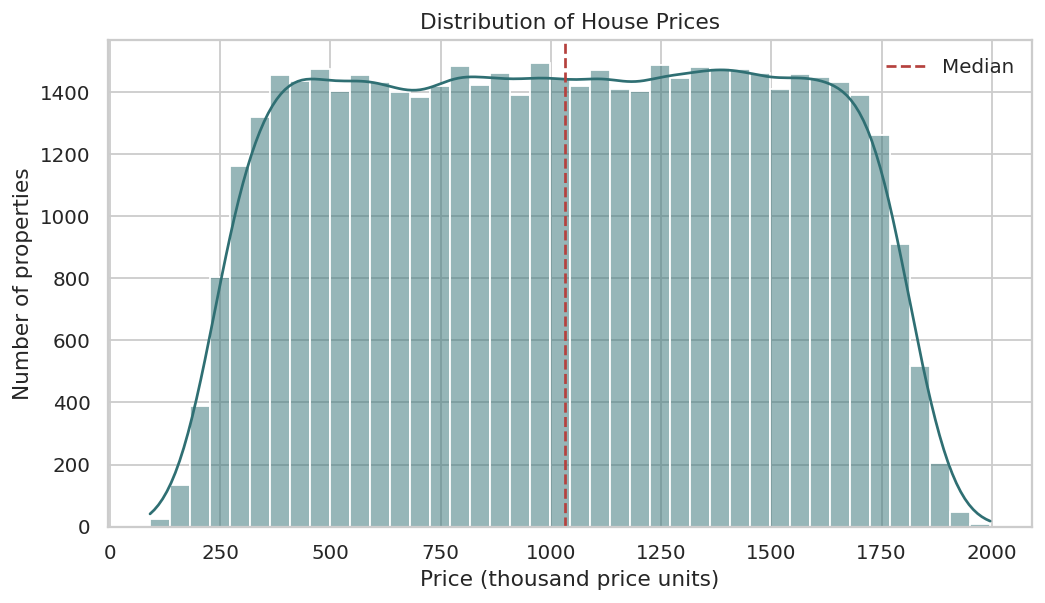

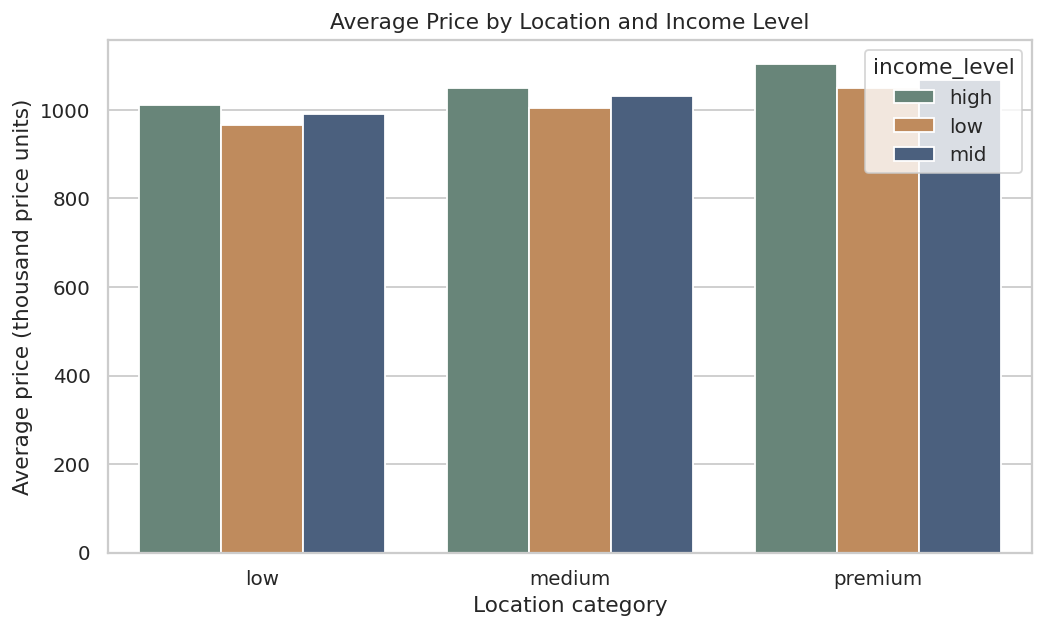

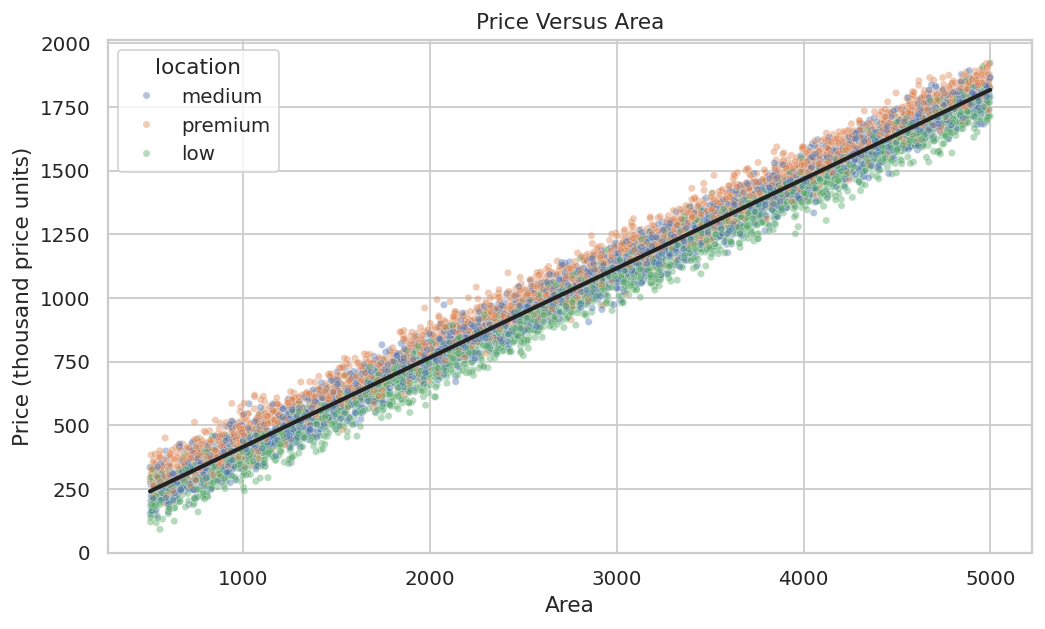

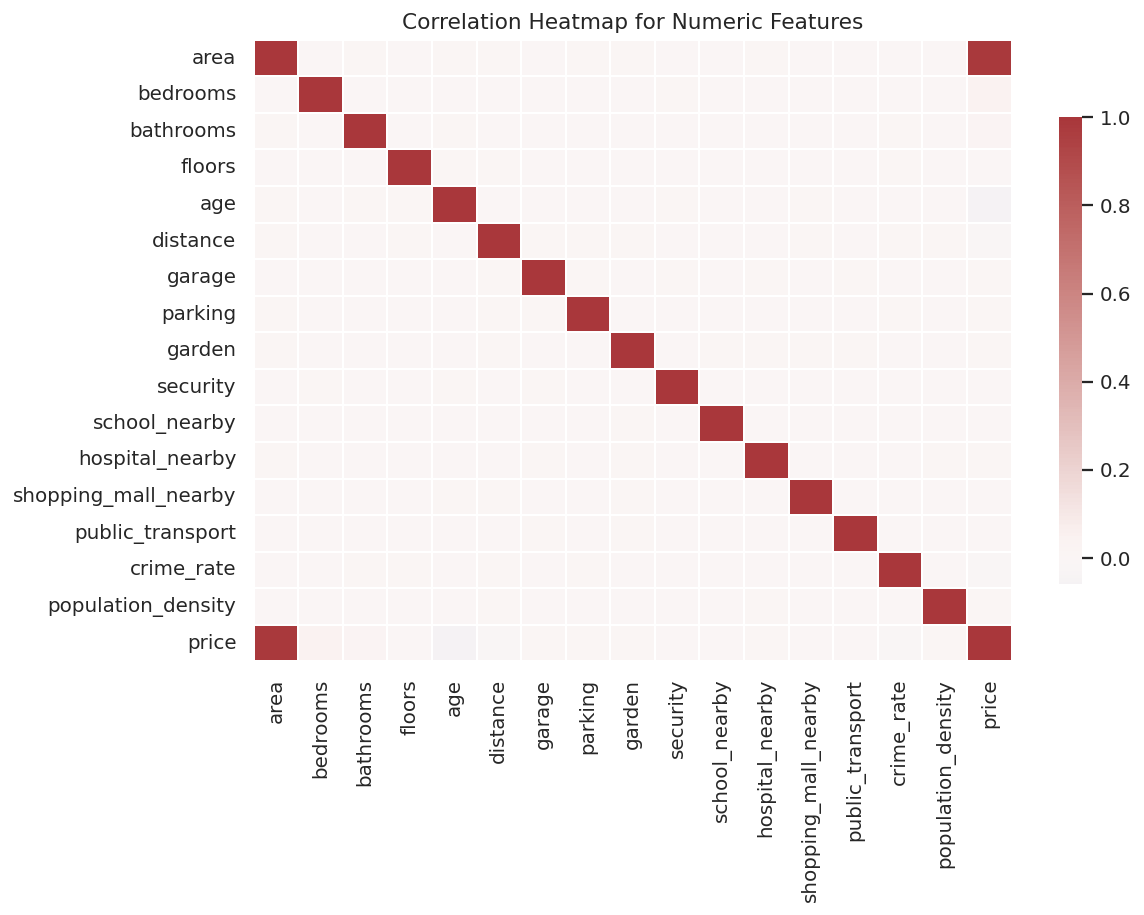

In [24]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
sns.histplot(df["price"] / 1000, bins=42, kde=True, color="#2f6f73", ax=ax)
ax.axvline(df["price"].median() / 1000, color="#b5413e", linestyle="--", label="Median")
ax.set_title("Distribution of House Prices")
ax.set_xlabel("Price (thousand price units)")
ax.set_ylabel("Number of properties")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_01_price_distribution.png", bbox_inches="tight")
plt.show()

grouped = df.groupby(["location", "income_level"], as_index=False)["price"].mean()
fig, ax = plt.subplots(figsize=(8.2, 5.0))
sns.barplot(data=grouped, x="location", y=grouped["price"] / 1000, hue="income_level", palette=["#638a7a", "#cf8a4d", "#425f87"], ax=ax)
ax.set_title("Average Price by Location and Income Level")
ax.set_xlabel("Location category")
ax.set_ylabel("Average price (thousand price units)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_02_location_income_price.png", bbox_inches="tight")
plt.show()

sample = df.sample(n=min(8500, len(df)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8.2, 5.0))
sns.scatterplot(data=sample, x="area", y=sample["price"] / 1000, hue="location", alpha=0.42, s=16, ax=ax)
sns.regplot(data=sample, x="area", y=sample["price"] / 1000, scatter=False, color="#222222", ax=ax)
ax.set_title("Price Versus Area")
ax.set_xlabel("Area")
ax.set_ylabel("Price (thousand price units)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_03_price_vs_area.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 7.2))
corr = df[numeric_features + [target]].corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.25, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlation Heatmap for Numeric Features")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 10. Feature preparation

The target is `price`. The model uses physical property variables, amenities, nearby services, broad location category and income level.

In [25]:
X = df.drop(columns=[target])
y = df[target]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 18)
y shape: (50000,)


## 11. Train-test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 40000
Test rows: 10000


## 12. Linear Regression
## 13. Ridge Regression
## 14. Random Forest

In [27]:
models = {
    "Linear Regression": Pipeline([("preprocess", linear_preprocess), ("model", LinearRegression())]),
    "Ridge Regression": Pipeline([("preprocess", linear_preprocess), ("model", RidgeCV(alphas=np.array([0.1, 1.0, 10.0, 100.0])))]),
    "Random Forest": Pipeline([
        ("preprocess", tree_preprocess),
        ("model", RandomForestRegressor(n_estimators=120, max_depth=18, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}
print(list(models.keys()))

['Linear Regression', 'Ridge Regression', 'Random Forest']


## 15. Cross-validation
## 16. Model comparison

In [28]:
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"}

metrics_rows = []
predictions = {}
fitted_models = {}
for name, model in models.items():
    cv_result = cross_validate(model, X_train, y_train, scoring=scoring, cv=cv, n_jobs=1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    metrics_rows.append({
        "model": name,
        "mae": mean_absolute_error(y_test, pred),
        "mse": mse,
        "rmse": np.sqrt(mse),
        "r2": r2_score(y_test, pred),
        "cv_mae": -cv_result["test_mae"].mean(),
        "cv_rmse": -cv_result["test_rmse"].mean(),
        "cv_r2": cv_result["test_r2"].mean(),
    })
    predictions[name] = pred
    fitted_models[name] = model

metrics_df = pd.DataFrame(metrics_rows).sort_values("rmse").reset_index(drop=True)
best_model_name = metrics_df.loc[0, "model"]
print("Best model:", best_model_name)
metrics_df

Best model: Ridge Regression


,model,mae,mse,rmse,r2,cv_mae,cv_rmse,cv_r2
0,Ridge Regression,15954.165759,3.976370e+08,19940.838378,0.998112,15986.565766,20018.409993,0.998087
1,Linear Regression,15954.172745,3.976375e+08,19940.848786,0.998112,15986.554204,20018.409820,0.998087
2,Random Forest,21664.521919,7.396912e+08,27197.264407,0.996488,22645.307805,28298.454594,0.996178


## 17. Actual-versus-predicted analysis

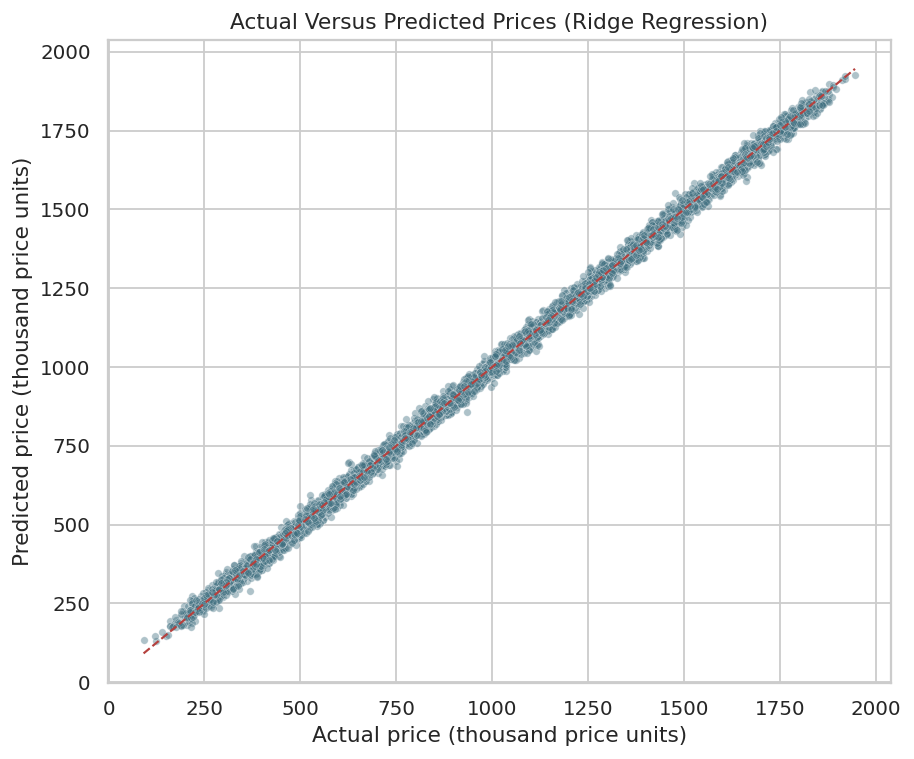

In [29]:
best_pred = predictions[best_model_name]
pred_df = X_test.copy().reset_index(drop=True)
pred_df["actual_price"] = y_test.reset_index(drop=True)
pred_df["predicted_price"] = best_pred
pred_df["absolute_error"] = (pred_df["actual_price"] - pred_df["predicted_price"]).abs()
pred_df["percentage_error"] = pred_df["absolute_error"] / pred_df["actual_price"]

plot_sample = pred_df.sample(n=min(5500, len(pred_df)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(7.2, 6.0))
sns.scatterplot(x=plot_sample["actual_price"] / 1000, y=plot_sample["predicted_price"] / 1000, alpha=0.42, s=17, color="#3f6f80", ax=ax)
low = min(plot_sample["actual_price"].min(), plot_sample["predicted_price"].min()) / 1000
high = max(plot_sample["actual_price"].max(), plot_sample["predicted_price"].max()) / 1000
ax.plot([low, high], [low, high], color="#b5413e", linestyle="--", linewidth=1.2)
ax.set_title(f"Actual Versus Predicted Prices ({best_model_name})")
ax.set_xlabel("Actual price (thousand price units)")
ax.set_ylabel("Predicted price (thousand price units)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_05_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

## 18. Feature importance

#### Fix for `NameError`

This cell defines `pred_df` to resolve a `NameError` in the subsequent cell, ensuring that `pred_df` is available for use. This code is extracted from the 'Actual-versus-predicted analysis' cell (`bK4aZhcYyIJr`). It is crucial that the model training and prediction cells (such as '16. Model comparison' (`oarsiG-dyIJr`)) have been run successfully to provide the necessary variables like `predictions` and `best_model_name`.

In [32]:
best_pred = predictions[best_model_name]
pred_df = X_test.copy().reset_index(drop=True)
pred_df["actual_price"] = y_test.reset_index(drop=True)
pred_df["predicted_price"] = best_pred
pred_df["absolute_error"] = (pred_df["actual_price"] - pred_df["predicted_price"]).abs()
pred_df["percentage_error"] = pred_df["absolute_error"] / pred_df["actual_price"]

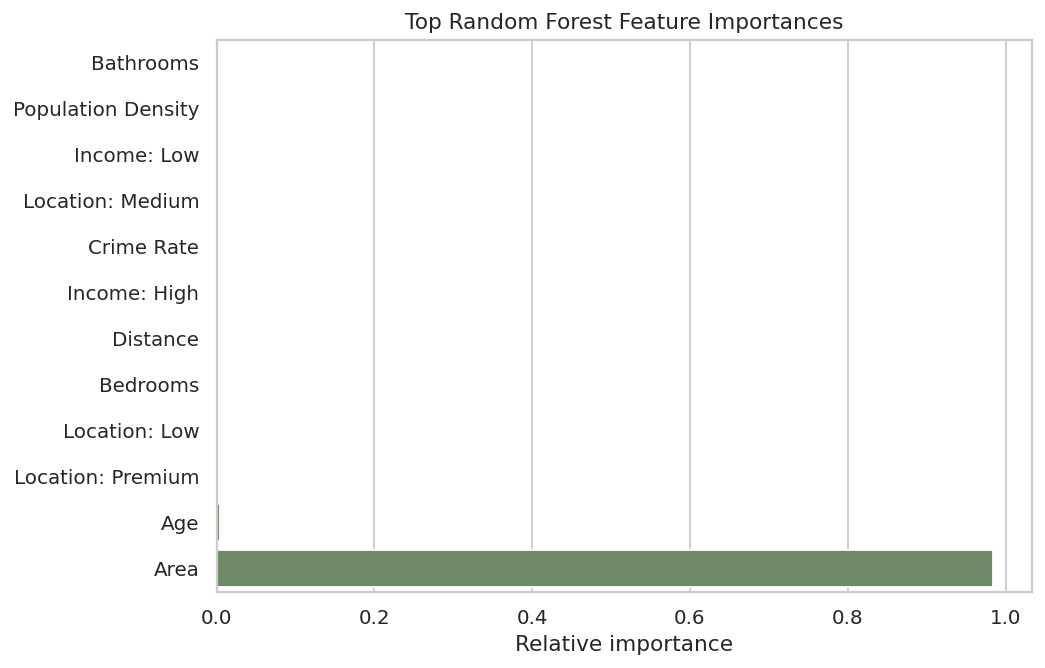

,feature,importance,feature_clean
0,area,0.984444,Area
1,age,0.004122,Age
2,location_premium,0.002180,Location: Premium
3,location_low,0.002156,Location: Low
4,bedrooms,0.001826,Bedrooms
5,distance,0.001188,Distance
6,income_level_high,0.001153,Income: High
7,crime_rate,0.000610,Crime Rate
8,location_medium,0.000488,Location: Medium
9,income_level_low,0.000448,Income: Low


In [33]:
rf_pipe = fitted_models["Random Forest"]
feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df["feature_clean"] = (
    importance_df["feature"]
    .str.replace("location_", "location: ", regex=False)
    .str.replace("income_level_", "income: ", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
top = importance_df.head(12).sort_values("importance")
fig, ax = plt.subplots(figsize=(8.2, 5.3))
sns.barplot(data=top, x="importance", y="feature_clean", color="#6c8e5f", ax=ax)
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Relative importance")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_06_feature_importance.png", bbox_inches="tight")
plt.show()
importance_df.head(10)

## 19. Tableau export

In [34]:
df.to_csv(TABLEAU_DIR / "cleaned_house_price_50k.csv", index=False)
pred_df.to_csv(TABLEAU_DIR / "model_predictions.csv", index=False)
metrics_df.to_csv(TABLEAU_DIR / "model_metrics.csv", index=False)
importance_df.to_csv(TABLEAU_DIR / "feature_importance.csv", index=False)

df.groupby(["location", "income_level"]).agg(
    records=("price", "size"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    average_area=("area", "mean"),
    average_crime_rate=("crime_rate", "mean"),
    average_distance=("distance", "mean"),
).reset_index().to_csv(TABLEAU_DIR / "summary_by_location_income.csv", index=False)

df.groupby("location").agg(
    records=("price", "size"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    average_area=("area", "mean"),
    average_population_density=("population_density", "mean"),
).reset_index().to_csv(TABLEAU_DIR / "summary_by_location.csv", index=False)

df.select_dtypes(include=[np.number]).corr(numeric_only=True)["price"].sort_values(ascending=False).rename("correlation_with_price").to_frame().to_csv(TABLEAU_DIR / "numeric_correlations_with_price.csv")

(TABLEAU_DIR / "tableau_dashboard_build_note.md").write_text(
    "# Tableau Dashboard Build Note\n\n"
    "Use the cleaned dataset, model predictions, model metrics and feature importance files to build a dashboard. "
    "Suggested views: price distribution, location/income comparison, actual versus predicted prices, model metrics and feature importance.\n",
    encoding="utf-8",
)

sorted(p.name for p in TABLEAU_DIR.iterdir())

['cleaned_house_price_50k.csv',
 'feature_importance.csv',
 'model_metrics.csv',
 'model_predictions.csv',
 'numeric_correlations_with_price.csv',
 'summary_by_location.csv',
 'summary_by_location_income.csv',
 'tableau_dashboard_build_note.md']

## 20. Business interpretation

In [35]:
best = metrics_df.iloc[0]
print(f"Best model: {best['model']}")
print(f"MAE: {best['mae']:,.0f} price units")
print(f"RMSE: {best['rmse']:,.0f} price units")
print(f"R-squared: {best['r2'] * 100:.2f}%")
print("Main insight: area is the strongest driver, with location and income level adding market context.")

Best model: Ridge Regression
MAE: 15,954 price units
RMSE: 19,941 price units
R-squared: 99.81%
Main insight: area is the strongest driver, with location and income level adding market context.


## 21. Limitations

The Kaggle metadata does not prove country, currency, transaction date or official collection method. The results are valid for this dataset and academic project, but a live valuation tool would need richer verified market data.

## 22. Final summary

In [36]:
expected = {
    "mae": 15954,
    "rmse": 19941,
    "r2_pct": 99.81,
}
best = metrics_df.iloc[0]
print("Final checked results")
print("---------------------")
print(f"Model: {best['model']}")
print(f"MAE: {best['mae']:,.0f} price units")
print(f"RMSE: {best['rmse']:,.0f} price units")
print(f"R-squared: {best['r2'] * 100:.2f}%")

if round(best["mae"]) != expected["mae"] or round(best["rmse"]) != expected["rmse"] or round(best["r2"] * 100, 2) != expected["r2_pct"]:
    raise AssertionError("Notebook metrics do not match the final report values.")

print("Metrics match the final report.")

Final checked results
---------------------
Model: Ridge Regression
MAE: 15,954 price units
RMSE: 19,941 price units
R-squared: 99.81%
Metrics match the final report.
